In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
x = pd.read_table('x.txt',header=None,names=['x'])
N = 200
T_min, T_max = 1,1000
T = np.array([T_min * np.exp(np.log(T_max/T_min)*i/(N-1)) for i in range(N)])

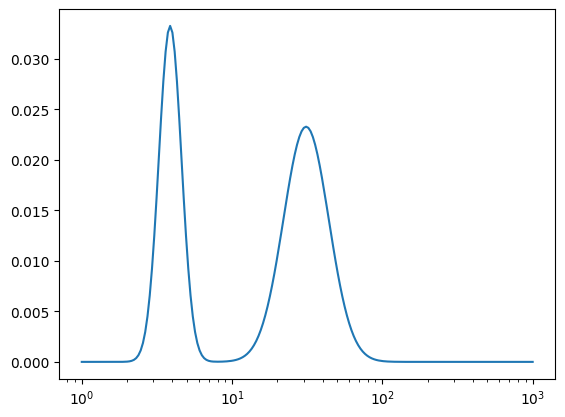

In [4]:
plt.plot(T,x)
plt.xscale('log')

In [5]:
M = 50
tmin, tmax = 0,1.5
t = np.array([tmin + (tmax - tmin)*i/(M-1) for i in range(M)])
K = np.exp(-np.outer(t,T))

In [ ]:
z = K@x.x
sigma = 0.01 * z[0]
w = np.random.normal(loc=np.zeros(M), scale=sigma,size=(M,))
y = z + w
xmin, xmax = np.min(x.x), np.max(x.x)

4.4885159000000005e-24 0.03324519


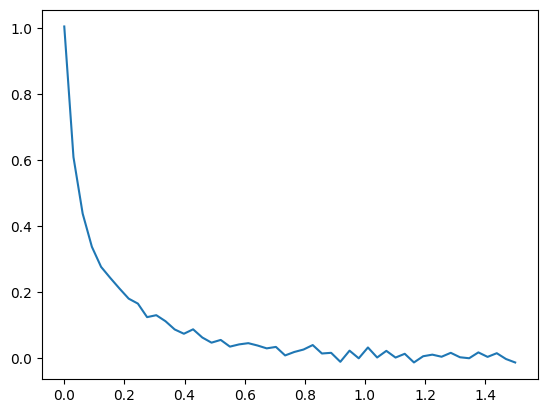

In [8]:
plt.plot(t, y)

Smootheness prior + constraint :

Best beta: 1.6681005372000592
Minimum NQE: 0.17174223217896933


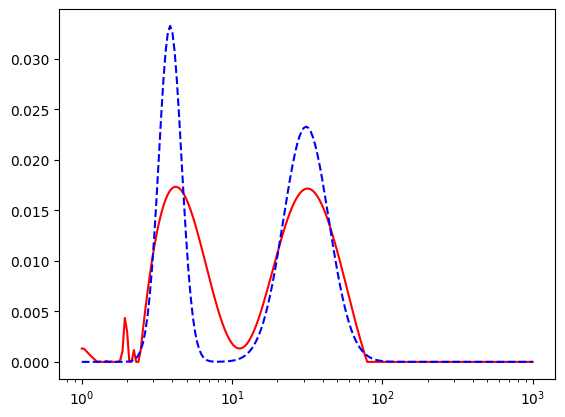

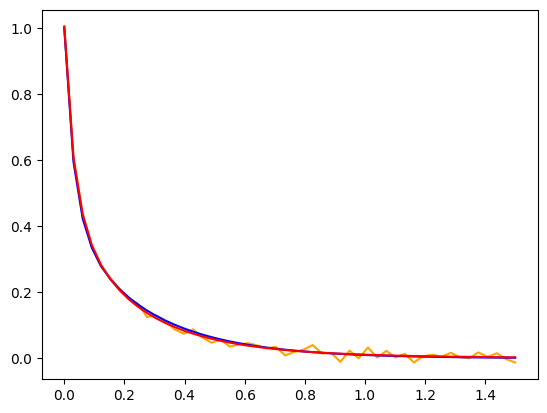

In [18]:
def g(x,x_min = -np.inf,x_max= np.inf):
    init_val = 0
    D = 0
    for i in range(len(x)):
        if x[i] < x_min:
            return np.inf
        elif x[i] > x_max:
            return np.inf
        else:
            D += (x[i]-init_val)**2
            init_val = x[i]
    return 0.5*D

def f(x):
    Kx = K @ x
    return np.sqrt(np.sum((Kx - y)**2))

from scipy.optimize import minimize
grid_beta = np.logspace(-2,2,10)
NQE_list = [] 


## Naive optimization
for beta in grid_beta:
    res = minimize(lambda x: f(x) + beta*g(x), x0=0.01*np.ones(N), method='L-BFGS-B', bounds=[(xmin,xmax)]*N)
    NQE = np.sum(((res.x - x.x)**2))/np.sum((x.x**2))
    NQE_list.append(NQE)

best_beta = grid_beta[np.argmin(NQE_list)]
res = minimize(lambda x: f(x) + best_beta*g(x), x0=0.01*np.ones(N), method='L-BFGS-B', bounds=[(xmin,xmax)]*N)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
plt.plot(T, res.x, label='Reconstructed', color='red')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

plt.plot(t, y, label='Noisy data', color='orange')
plt.plot(t, x.x @ K.T, label='Perfectly dennoised data', color='blue')
plt.plot(t, res.x @ K.T, label='Denoised GD data', color='red')
plt.show()


NQE Forward-Backward: 2.38915784479373e+41


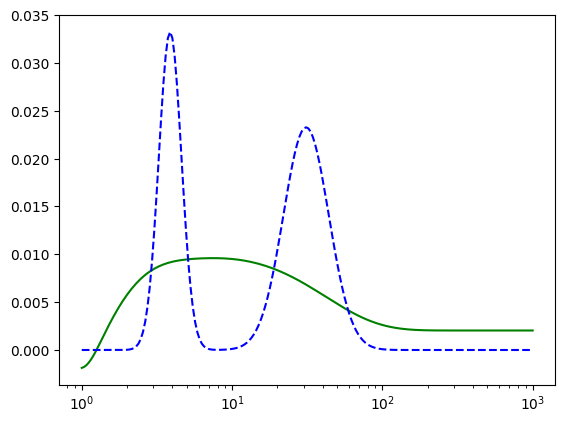

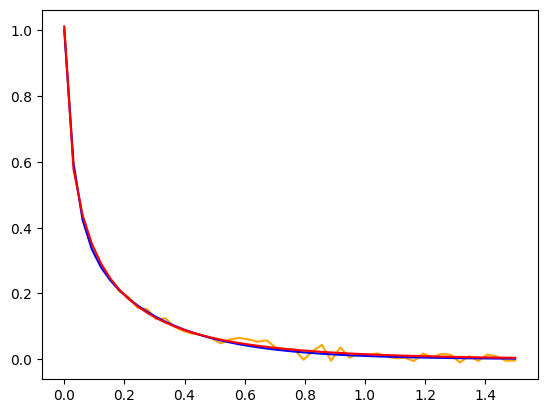

In [ ]:
## Forward - Backward optimization
import numpy as np
def proximal_g(v, gamma, xmin=None, xmax=None):
    """
    Solution du problème de minimisation
    (I/gamma + D^T D) x = v/gamma
    puis on projette sur [xmin, xmax].
    """
    N = len(v)
    main_diag = np.ones(N) * (1.0/gamma + 2.0)
    main_diag[0]  = 1.0/gamma + 1.0
    main_diag[-1] = 1.0/gamma + 1.0

    off_diag = np.ones(N-1) * (-1.0)
    b = v / gamma
    x = np.linalg.solve(np.diag(main_diag) + np.diag(off_diag, k=1) + np.diag(off_diag, k=-1), b)
    # x = np.clip(x, xmin, xmax)
    return x

def prox_f(v, gamma, K, y):
    A = K.T @ K + (1.0 / gamma) * np.eye(K.shape[1])
    rhs = K.T @ y + (1.0 / gamma) * v
    x = np.linalg.solve(A, rhs)
    return x

def forward_backward_optimization(beta, x_init, K, y, max_iter=100):
    x_curr = x_init.copy()
    lipschitz_const = np.linalg.norm(K, ord=2)**2
    gamma = 1 / lipschitz_const
    lambda_curr = 1

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y))
        # Backward
        x_next = x_curr + lambda_curr * (proximal_g(y_curr, beta * gamma) - x_curr)

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(10, np.ones(N), K, y, max_iter=500)
NQE_fb = np.sum(((res_fb - x.x)**2)/(x.x**2))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

plt.plot(t, y, label='Noisy data', color='orange')
plt.plot(t, x.x @ K.T, label='Perfectly dennoised data', color='blue')
plt.plot(t, res_fb @ K.T, label='Denoised GD data', color='red')
plt.show()

fin


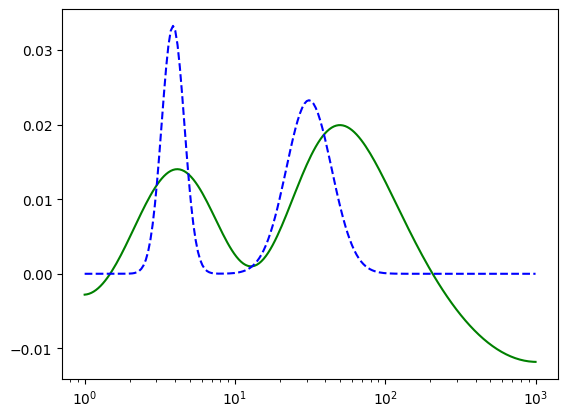

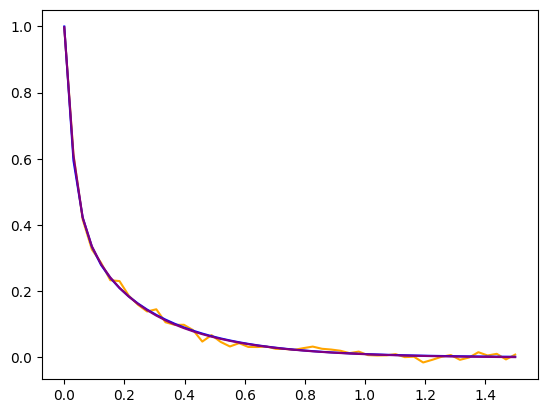

In [56]:
def douglas_rachford(K, y, beta, x0, gamma, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    for n in range(n_iter):      
        tau = gamma * beta
        yn = proximal_g(xn, tau)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)

        xn1 = xn + lamb * (zn - yn)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            break

        xn = xn1

    x_est = proximal_g(xn, tau) 
    return x_est

x0 = np.zeros(N)
x_sol = douglas_rachford(K, y, beta = 10, x0 = x0, gamma = 1, n_iter=200, lamb = 1, tol=1e-6) 
print("fin")

plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

plt.plot(t, y, label='Noisy data', color='orange')
plt.plot(t, x.x @ K.T, label='Perfectly dennoised data', color='blue')
plt.plot(t, x_sol @ K.T, label='Denoised GD data', color='purple')
plt.show()


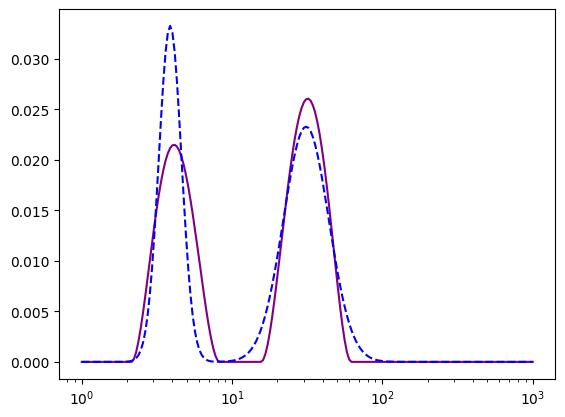

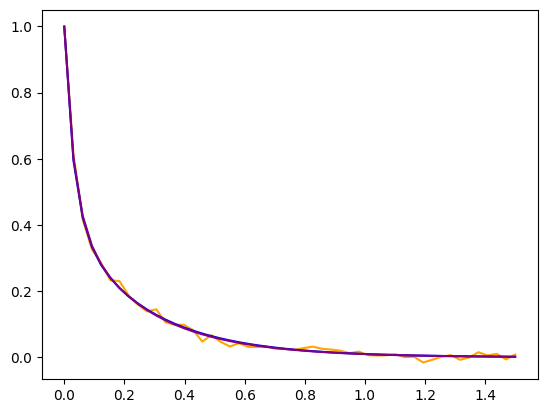

In [57]:
D = np.zeros((N-1,N))
for i in range(N-1):
    D[i,i] = -1
    D[i,i+1] = 1 
def grad(x, beta, K, y):
    return K.T @ (K @ x - y) + beta * D.T @ (D @ x)
def gradient_descent(K, y, beta, x0, n_iter=200, tol=1e-6, clipping=True):
    xn = x0.copy()
    yn = xn
    gamma = 2 / (np.linalg.norm(K, ord=2)**2 + beta * np.linalg.norm(D, ord=2)**2)
    lamb = 1.0
    for n in range(n_iter):
        grad_xn = grad(xn, beta, K, y)
        if clipping:
            yn = xn - gamma * grad_xn
            xn1 = xn + lamb * (np.clip(yn, 0, 1e3) - xn)
        else:
            xn1 = xn - gamma * grad_xn
        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            break
        xn = xn1
    return xn

x0 = np.zeros(N)
x_sol = gradient_descent(K, y, beta = 10e-1, x0 = x0, n_iter=20000, tol=1e-6, clipping=True) 
plt.plot(T, x_sol, label='Reconstructed GD', color='purple')
plt.plot(T, x.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

plt.plot(t, y, label='Noisy data', color='orange')
plt.plot(t, x.x @ K.T, label='Perfectly dennoised data', color='blue')
plt.plot(t, x_sol @ K.T, label='Denoised GD data', color='purple')
plt.show()